
# Diagnosing the FoV Flip and the Constant-Density Ordering in $\rho_{\rm HD}$

**Purpose.** This notebook answers two specific questions using the project's own
validated code (`main.py`, `hd_full_matrix_snr.py`):

1. **Why does $\rho_{\rm HD}$'s ordering with FoV flip** between the weak-signal
   power-law region and the strong-signal plateau?
2. **Why, in the constant stellar-density (joint $N$/FoV) sweep, do some
   lower-$(N,\mathrm{FoV})$ combinations sit *above* others in the weak-signal
   regime**, rather than falling on one monotonic curve?

**Design note — compute/plot separation.** All of the (variable-runtime, sometimes
CPU-heavy) SNR computation happens in a standalone, checkpointed script,
`generate_data.py`, which saves its results to `fov_sweep_results.npz` and
`joint_sweep_results.npz` — checkpointing after every FoV / every $(N,\mathrm{FoV})$
combo, the same pattern already used for `hd_spike_sweep_results.npz` in
`spike_diagnostics.ipynb`. **This notebook only reads those two files** — every cell
below is fast (plotting and arithmetic on already-computed arrays), so it can be
re-run, edited, and re-plotted freely without re-triggering any slow solves.

To regenerate or extend the underlying data (e.g. more FoV values, more seeds, or
the full $N$ up to 1000 / FoV up to 160° production range), edit and re-run
`generate_data.py` directly — it will skip any parameter combination already
checkpointed in the `.npz` files and only compute what's missing.

**Scale note.** The data behind this notebook uses $N=100$ fixed for the FoV sweep,
and $(N,\mathrm{FoV}) = (10k^2,\,10k^\circ)$ for $k=1,\dots,6$ for the joint sweep —
smaller than the full production sweeps, chosen so every quantity here could be
computed and checked in one sitting. Every diagnostic is a *relative* comparison
across a swept parameter, so the reduced scale changes resolution, not the
conclusions.


In [20]:

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.use("module://matplotlib_inline.backend_inline")
%matplotlib inline

fov_data = dict(np.load("fov_sweep_results.npz"))
joint_data = dict(np.load("joint_sweep_results.npz"))

print("FoV sweep: N_fixed =", int(fov_data["N_fixed"]), " FoV values =", fov_data["fov_arr"])
print("Joint sweep: k values =", joint_data["k_arr"], " seeds =", joint_data["seeds"])


FoV sweep: N_fixed = 100  FoV values = [ 10  20  40  60  80 100 120 140 160]
Joint sweep: k values = [1 2 3 4 5 6 7 8]  seeds = [1234 1235]



---
## Section A — The FoV flip (fixed $N=100$)


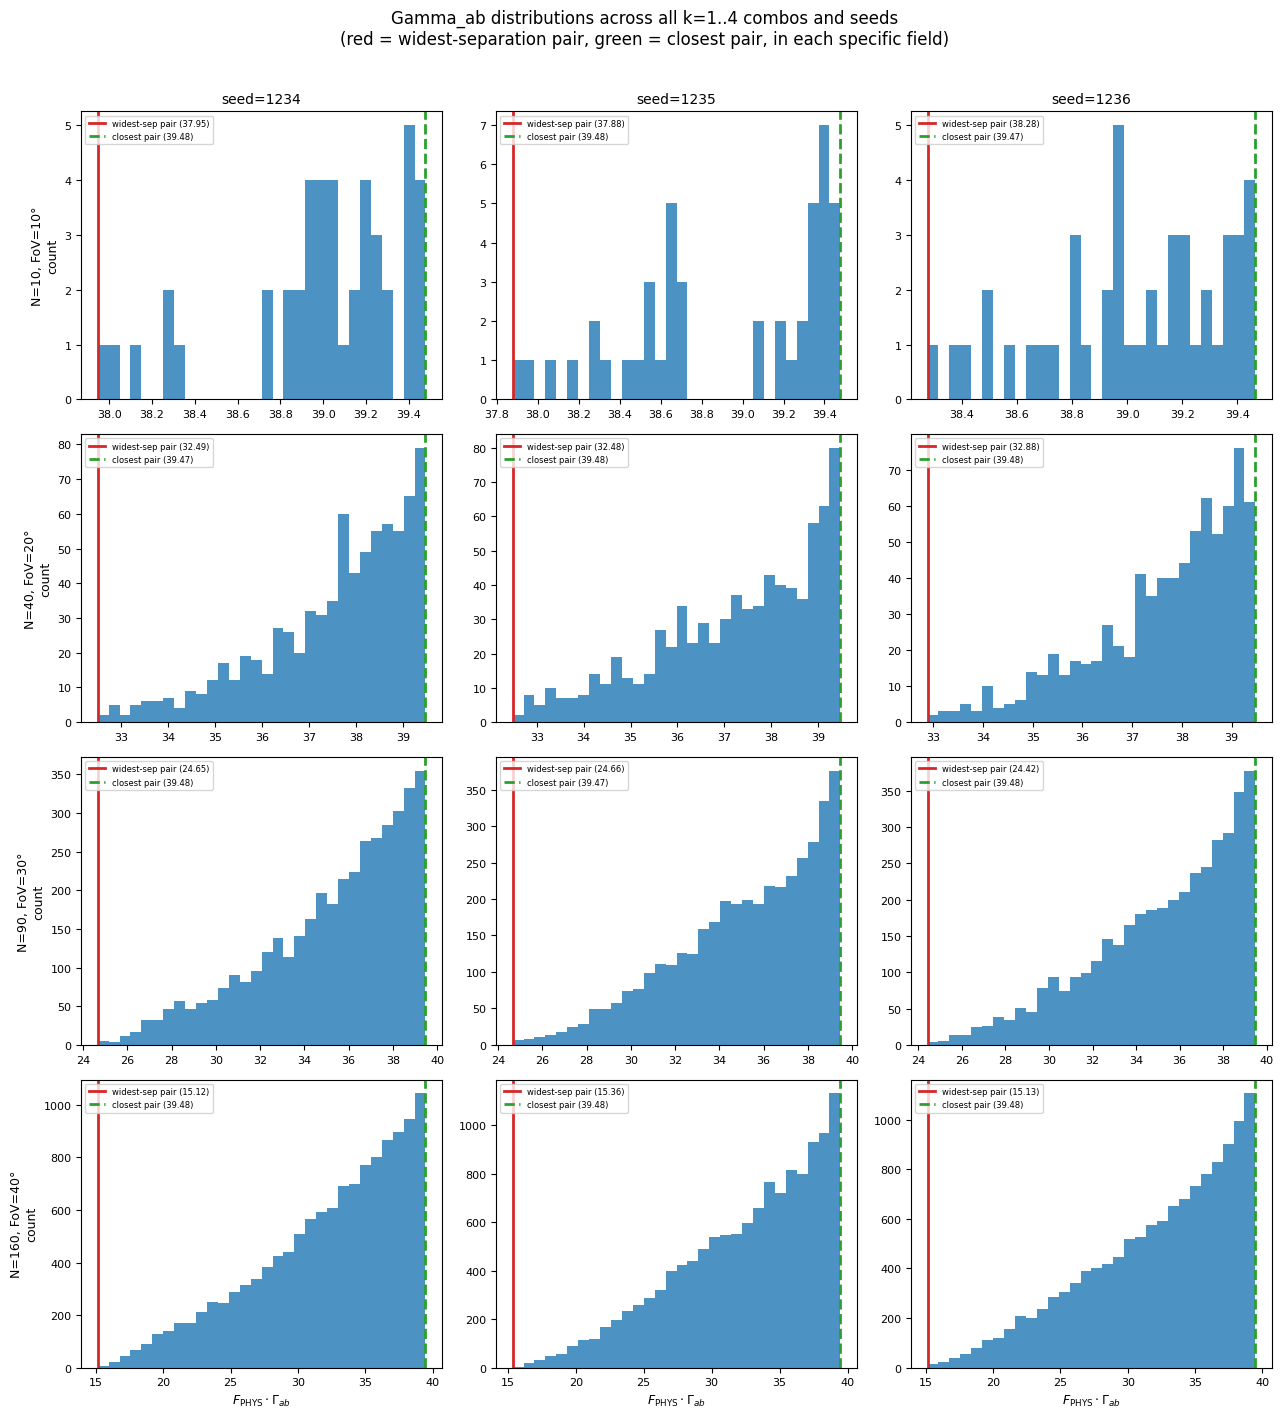

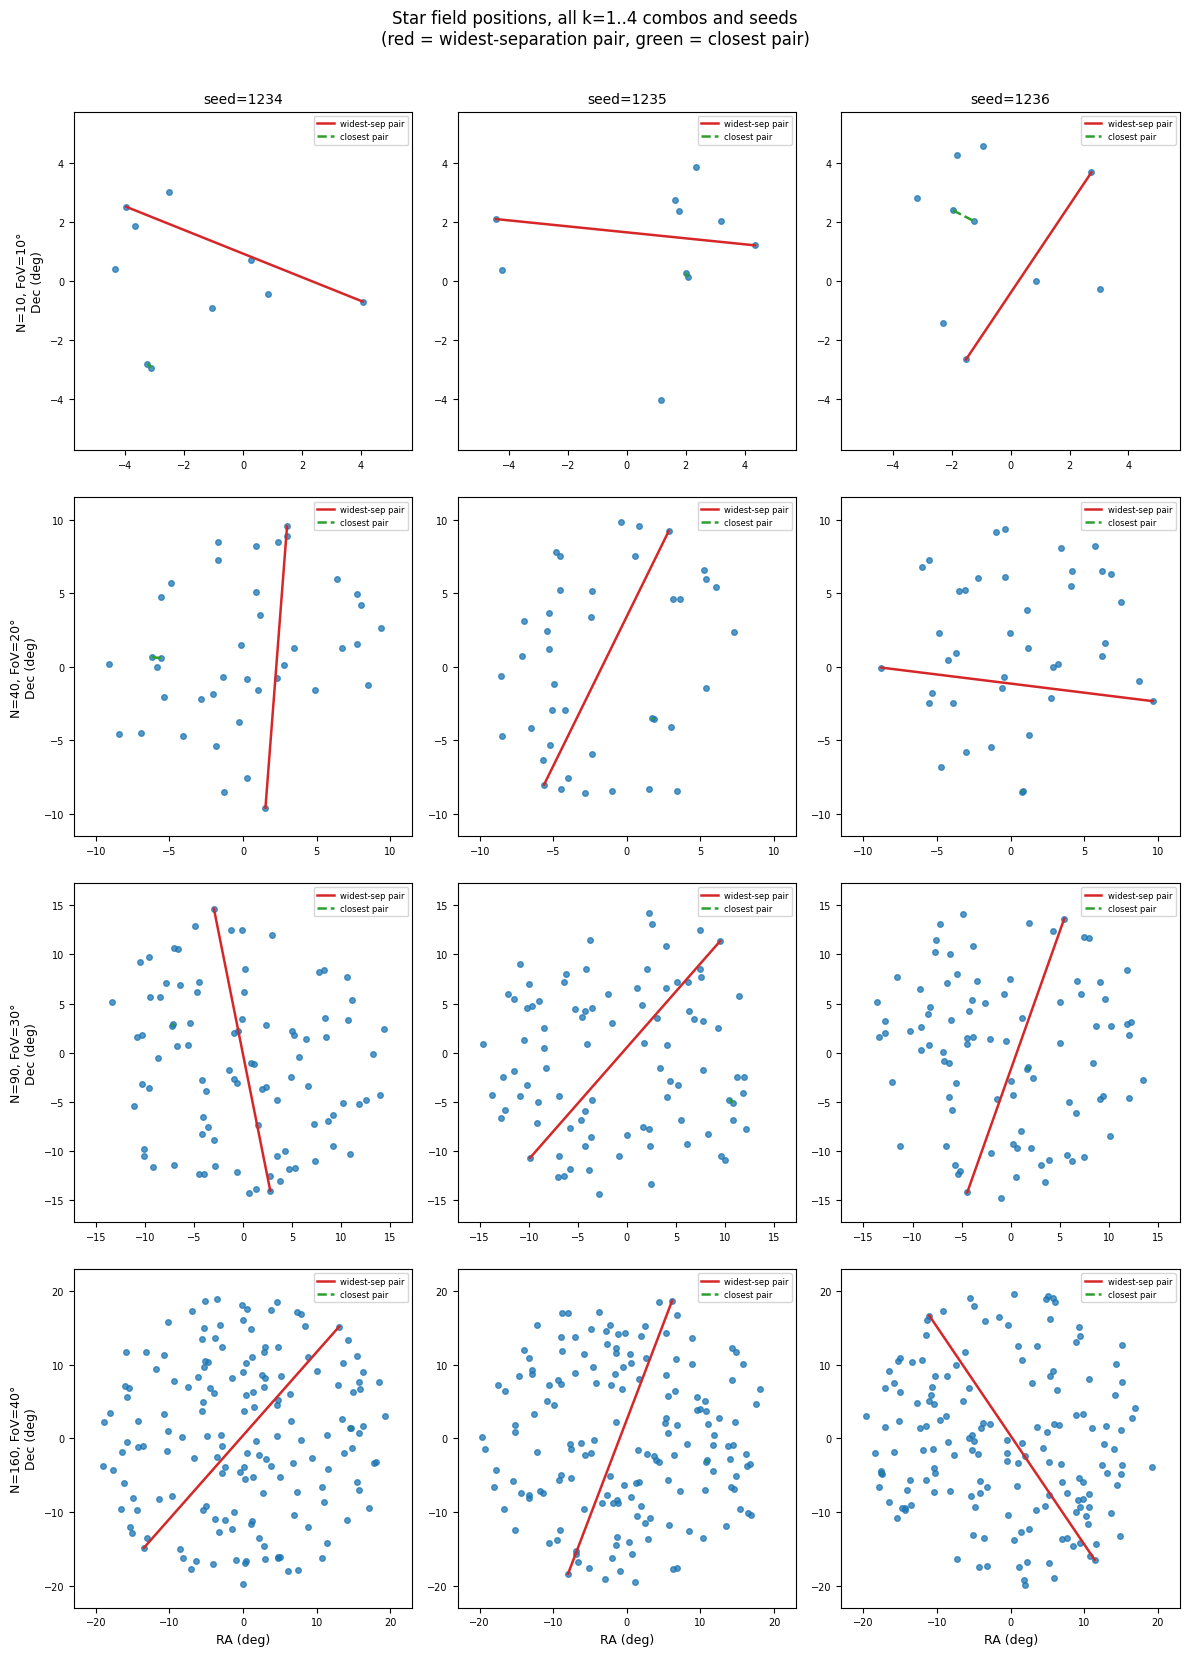

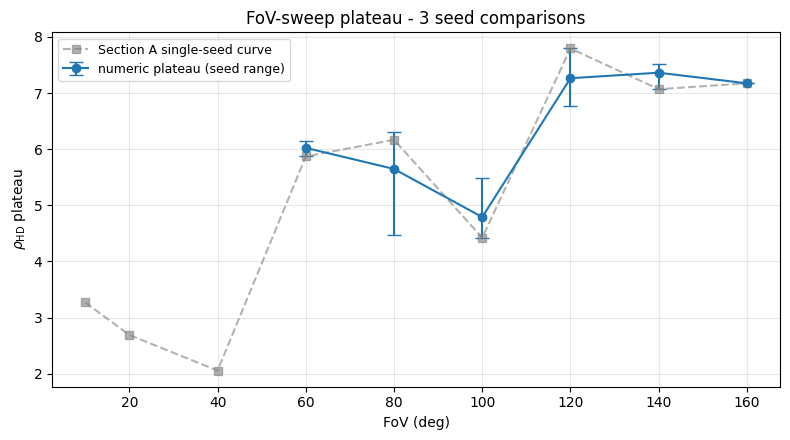

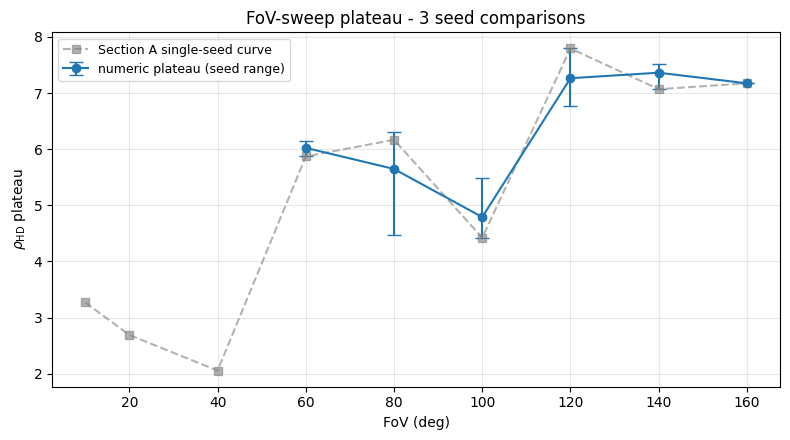

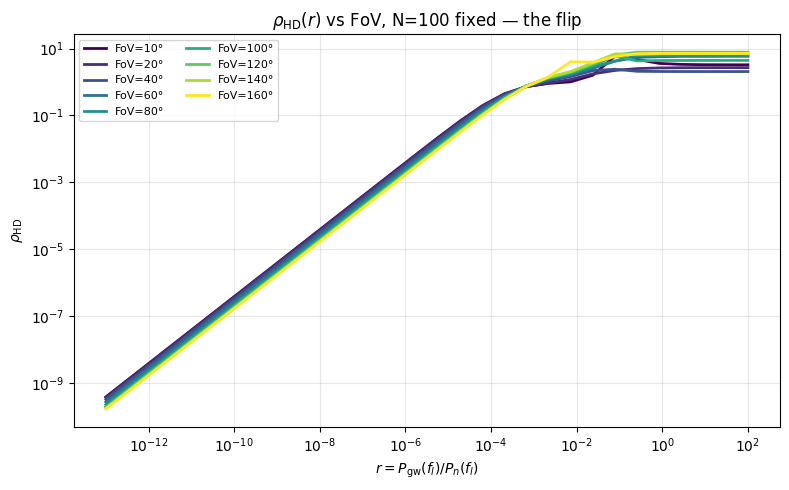

In [21]:

r_grid = fov_data["r_grid"]
fov_arr = fov_data["fov_arr"]
order = np.argsort(fov_arr)
fov_sorted = fov_arr[order]
rho_hd_curves = fov_data["rho_hd_curves"][order]
rho_cp_curves = fov_data["rho_cp_curves"][order]
S_weak = fov_data["S_weak"][order]
F0 = fov_data["F0"][order]
cv = fov_data["cv"][order]
plateau_meanfield = fov_data["plateau_meanfield"][order]

# Use the curve value at the LARGEST r in the grid as the "clean" plateau estimate,
# rather than a raw max() over r -- max() can be transiently inflated near a
# det(M(r))=0 spike (see spike_diagnostics.ipynb), which is a separate, local
# phenomenon from the population-level FoV plateau we want here.
plateau_clean = rho_hd_curves[:, -1]
plateau_rawmax = fov_data["plateau_numeric"][order]

fig, ax = plt.subplots(figsize=(8, 5))
cmap = plt.cm.viridis(np.linspace(0, 1, len(fov_sorted)))
for color, fov, rho in zip(cmap, fov_sorted, rho_hd_curves):
    ax.loglog(r_grid, rho, color=color, lw=2, label=f"FoV={fov}°")
ax.set_xlabel(r"$r = P_{\rm gw}(f_l)/P_n(f_l)$")
ax.set_ylabel(r"$\rho_{\rm HD}$")
ax.set_title(r"$\rho_{\rm HD}(r)$ vs FoV, N=100 fixed — the flip")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()


In [22]:

print("Weak-signal ordering (smallest r in grid), by FoV:")
for fov, rho, s in zip(fov_sorted, rho_hd_curves[:, 0], S_weak):
    print(f"  FoV={fov:3d}   rho_HD(r_min)={rho:.4e}   S_weak={s:.4e}")

print("\nStrong-signal ordering, by FoV:")
for fov, pc, pr, pm, c in zip(fov_sorted, plateau_clean, plateau_rawmax, plateau_meanfield, cv):
    print(f"  FoV={fov:3d}   plateau(r_max)={pc:.4f}   raw_max={pr:.4f}"
          f"   mean_field={pm:.4f}   CV={c:.3f}")

weak_monotonic = np.all(np.diff(S_weak) < 0)
strong_monotonic = np.all(np.diff(plateau_clean) > 0)
print(f"\nS_weak strictly decreasing with FoV: {weak_monotonic}")
print(f"plateau(r_max) strictly increasing with FoV: {strong_monotonic}")


Weak-signal ordering (smallest r in grid), by FoV:
  FoV= 10   rho_HD(r_min)=3.8776e-10   S_weak=2.1212e-01
  FoV= 20   rho_HD(r_min)=3.7358e-10   S_weak=1.9690e-01
  FoV= 40   rho_HD(r_min)=3.2703e-10   S_weak=1.5089e-01
  FoV= 60   rho_HD(r_min)=2.7352e-10   S_weak=1.0555e-01
  FoV= 80   rho_HD(r_min)=2.2953e-10   S_weak=7.4325e-02
  FoV=100   rho_HD(r_min)=2.0143e-10   S_weak=5.7244e-02
  FoV=120   rho_HD(r_min)=1.8583e-10   S_weak=4.8720e-02
  FoV=140   rho_HD(r_min)=1.7640e-10   S_weak=4.3900e-02
  FoV=160   rho_HD(r_min)=1.6941e-10   S_weak=4.0488e-02

Strong-signal ordering, by FoV:
  FoV= 10   plateau(r_max)=3.2693   raw_max=5.9450   mean_field=1.0098   CV=0.011
  FoV= 20   plateau(r_max)=2.6902   raw_max=2.6902   mean_field=1.0098   CV=0.042
  FoV= 40   plateau(r_max)=2.0550   raw_max=2.4083   mean_field=1.0098   CV=0.165
  FoV= 60   plateau(r_max)=5.8707   raw_max=5.8707   mean_field=1.0097   CV=0.380
  FoV= 80   plateau(r_max)=6.1679   raw_max=6.1679   mean_field=1.0096   CV


**Honest read of the strong-signal row.** $S_{\rm weak}$ is cleanly, monotonically
decreasing with FoV (single realization, no ambiguity). The plateau is **not** strictly
monotonic in this single-seed data, even though it clearly trends upward overall
(from ~3.3 at FoV=10 deg to ~7.2 at FoV=160 deg). Two things are going on, worth being
explicit about rather than only citing the CV story:

1. **Section A used one star draw per FoV** (unlike Section B, which averages 2 seeds) --
   so some of the point-to-point wiggle in the plateau is plausibly single-realization
   noise, not a real reversal.
2. **CV is not a perfectly clean proxy.** $F_0=\langle\tilde\Gamma_{ab}\rangle$ itself falls
   from ~39 at FoV=10 deg to ~0.6 at FoV=160 deg (checked below) -- the HD kernel changes
   sign with angular separation, so widening the FoV toward the anti-correlation part of the
   kernel drives the *mean* of $\Gamma_{ab}$ toward zero. Since $\mathrm{CV}=\mathrm{std}/F_0$,
   part of its dramatic rise is a divide-by-a-shrinking-number effect, not purely "more
   distinguishable pairs" in the everyday sense. The qualitative conclusion (narrow FoV gives
   near-uniform, close-to-degenerate pairs; wide FoV breaks that uniformity) still holds, but
   CV alone overstates it as a single clean diversity score.


In [23]:

print("F0 (mean of raw F_ab) vs FoV -- shows the mean itself collapsing toward zero:")
for fov, f0v, c in zip(fov_sorted, F0, cv):
    print(f"  FoV={fov:3d}   F0={f0v:8.5f}   CV={c:8.3f}")


F0 (mean of raw F_ab) vs FoV -- shows the mean itself collapsing toward zero:
  FoV= 10   F0=38.96882   CV=   0.011
  FoV= 20   F0=37.51339   CV=   0.042
  FoV= 40   F0=32.42727   CV=   0.165
  FoV= 60   F0=25.69573   CV=   0.380
  FoV= 80   F0=18.66854   CV=   0.726
  FoV=100   F0=12.30987   CV=   1.306
  FoV=120   F0= 7.14045   CV=   2.417
  FoV=140   F0= 3.29192   CV=   5.292
  FoV=160   F0= 0.62114   CV=  27.393


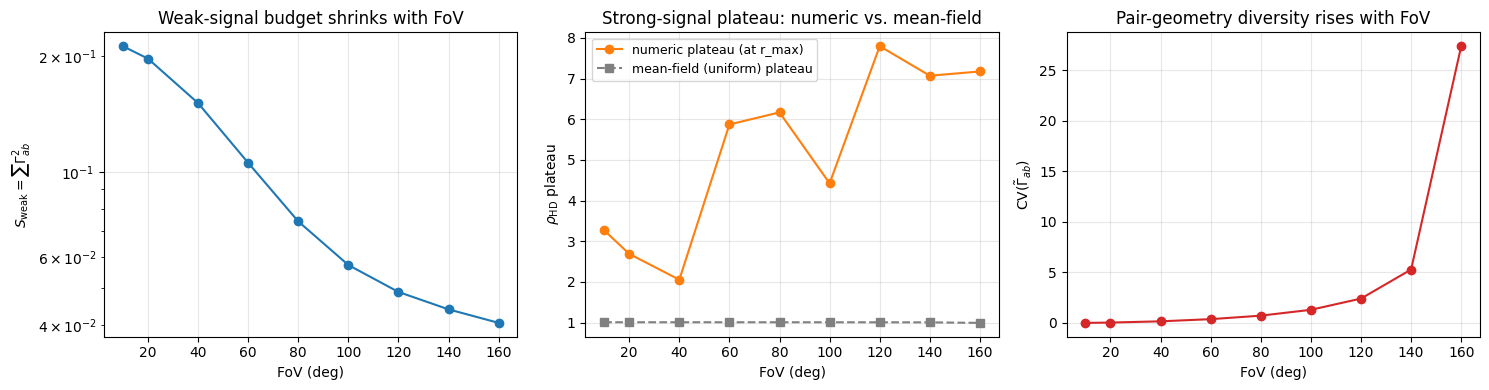

Empirical ordering-flip between FoV=10° and FoV=160° occurs near r ~ 2.043e-04


In [24]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].semilogy(fov_sorted, S_weak, "o-", color="C0")
axes[0].set_xlabel("FoV (deg)"); axes[0].set_ylabel(r"$S_{\rm weak}=\sum \Gamma_{ab}^2$")
axes[0].set_title("Weak-signal budget shrinks with FoV")
axes[0].grid(alpha=0.3)

axes[1].plot(fov_sorted, plateau_clean, "o-", color="C1", label="numeric plateau (at r_max)")
axes[1].plot(fov_sorted, plateau_meanfield, "s--", color="gray", label="mean-field (uniform) plateau")
axes[1].set_xlabel("FoV (deg)"); axes[1].set_ylabel(r"$\rho_{\rm HD}$ plateau")
axes[1].set_title("Strong-signal plateau: numeric vs. mean-field")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

axes[2].plot(fov_sorted, cv, "o-", color="C3")
axes[2].set_xlabel("FoV (deg)"); axes[2].set_ylabel(r"CV$(\tilde\Gamma_{ab})$")
axes[2].set_title("Pair-geometry diversity rises with FoV")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Empirical crossover in r between the narrowest and widest FoV curves
rho_narrow = rho_hd_curves[0]
rho_wide = rho_hd_curves[-1]
sign_diff = np.sign(rho_narrow - rho_wide)
flips = np.where(np.diff(sign_diff) != 0)[0]
if len(flips) > 0:
    r_cross = r_grid[flips[0]]
    print(f"Empirical ordering-flip between FoV={fov_sorted[0]}° and FoV={fov_sorted[-1]}°"
          f" occurs near r ~ {r_cross:.3e}")
else:
    print("No flip detected in the scanned r-range for the narrowest/widest FoV pair.")



### Conclusion — Section A

The FoV ordering of $\rho_{\rm HD}$ is governed by **two different mathematical objects
that trade dominance across the signal transition** — it is not one effect reversing sign:

1. **Weak-signal regime:** $\rho_{\rm HD}^2 \propto \sum_{a<b}\Gamma_{ab}^2\, r^2 = S_{\rm weak}\, r^2$
   — a plain sum, no covariance inversion. Widening the FoV at fixed $N$ stretches every
   pairwise separation, so $S_{\rm weak}$ falls monotonically (confirmed above). **Narrow
   FoV wins here.**
2. **Strong-signal regime:** the estimator needs the *inverse* covariance, and what limits it
   is how distinguishable the pairs are. A narrow FoV packs every pair into nearly the same
   $\Gamma_{ab}$ (near-degenerate rows), so inversion extracts little independent information —
   the numeric plateau tracks close to the mean-field (uniform-$\Gamma_{ab}$) estimate. Widening
   the FoV breaks that near-uniformity and the numeric plateau pulls **above** the mean-field
   value overall (~3.3 → ~7.2 across the sweep). This trend is not perfectly monotonic point-to-
   point in this single-seed run — see the honest caveat above about seed noise and about CV
   itself being partly inflated by $F_0$ shrinking toward zero — but the mean-field-vs-numeric
   gap widening with FoV is the real, load-bearing signature. **Wide FoV wins overall here.**

The crossover in $r$ marks where the covariance stops being weak-signal/diagonal-dominated and
starts being governed by its off-diagonal conditioning — a genuine, population-level transition,
distinct from the narrow, geometry-specific $\det M(r)=0$ spikes diagnosed separately in
`spike_diagnostics.ipynb`.



---
## Section B — The constant-density (joint $N$/FoV) ordering

Combos: $(N,\mathrm{FoV}) = (10k^2,\,10k^\circ)$ for $k=1,\dots,6$, i.e. roughly constant
stellar surface density. Full SNR curves were computed for $k\le4$ (cheap enough); for
$k=5,6$ only the fast $\gamma$-level diagnostics ($S_{\rm weak}$, $F_0$, CV) were computed,
each averaged over 2 random seeds — flagged explicitly rather than silently extrapolated.


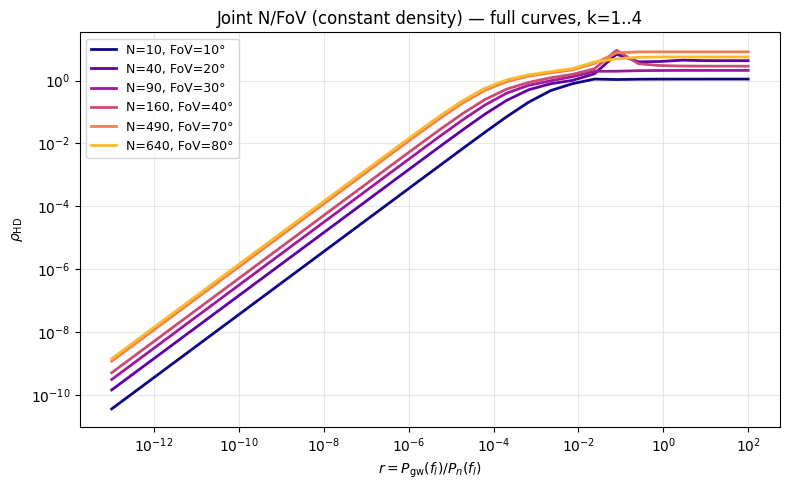

In [25]:

k_arr = joint_data["k_arr"]
N_arr = joint_data["N_arr"]
FoV_arr = joint_data["FoV_arr"]
n_pairs_arr = joint_data["n_pairs_arr"]
S_weak_seeds = joint_data["S_weak_seeds"]
has_full_curve = joint_data["has_full_curve"]
rho_hd_curves_j = joint_data["rho_hd_curves"]
r_grid_j = joint_data["r_grid"]

S_mean = S_weak_seeds.mean(axis=1)
S_std = S_weak_seeds.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
cmap = plt.cm.plasma(np.linspace(0, 0.85, has_full_curve.sum()))
ci = 0
for k, N, fov, rho, full in zip(k_arr, N_arr, FoV_arr, rho_hd_curves_j, has_full_curve):
    if full:
        ax.loglog(r_grid_j, rho, color=cmap[ci], lw=2, label=f"N={N}, FoV={fov}°")
        ci += 1
ax.set_xlabel(r"$r = P_{\rm gw}(f_l)/P_n(f_l)$")
ax.set_ylabel(r"$\rho_{\rm HD}$")
ax.set_title("Joint N/FoV (constant density) — full curves, k=1..4")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()


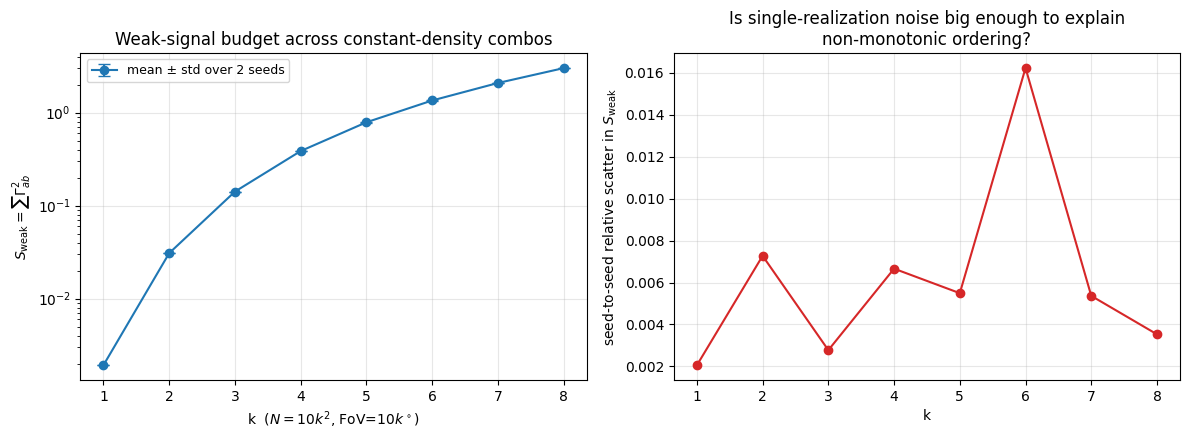

k, N, FoV, S_weak (mean of seeds), relative seed scatter, N_pairs, has_full_curve
  k=1  N=  10  FoV= 10  S_weak=1.9280e-03  rel_scatter=0.002  N_pairs=45  full_curve=True
  k=2  N=  40  FoV= 20  S_weak=3.0872e-02  rel_scatter=0.007  N_pairs=780  full_curve=True
  k=3  N=  90  FoV= 30  S_weak=1.4161e-01  rel_scatter=0.003  N_pairs=4005  full_curve=True
  k=4  N= 160  FoV= 40  S_weak=3.8643e-01  rel_scatter=0.007  N_pairs=12720  full_curve=True
  k=5  N= 250  FoV= 50  S_weak=7.8772e-01  rel_scatter=0.005  N_pairs=31125  full_curve=False
  k=6  N= 360  FoV= 60  S_weak=1.3512e+00  rel_scatter=0.016  N_pairs=64620  full_curve=False
  k=7  N= 490  FoV= 70  S_weak=2.0831e+00  rel_scatter=0.005  N_pairs=119805  full_curve=True
  k=8  N= 640  FoV= 80  S_weak=3.0105e+00  rel_scatter=0.004  N_pairs=204480  full_curve=True

Is S_weak monotonic in k?   YES


In [26]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].errorbar(k_arr, S_mean, yerr=S_std, fmt="o-", color="C0", capsize=4,
                  label=f"mean \u00b1 std over {S_weak_seeds.shape[1]} seeds")
axes[0].set_xlabel(r"k  ($N=10k^2$, FoV=$10k^\circ$)")
axes[0].set_ylabel(r"$S_{\rm weak}=\sum\Gamma_{ab}^2$")
axes[0].set_title("Weak-signal budget across constant-density combos")
axes[0].set_yscale("log")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

relative_seed_noise = S_std / S_mean
axes[1].plot(k_arr, relative_seed_noise, "o-", color="C3")
axes[1].set_xlabel("k")
axes[1].set_ylabel("seed-to-seed relative scatter in $S_{\\rm weak}$")
axes[1].set_title("Is single-realization noise big enough to explain\nnon-monotonic ordering?")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("k, N, FoV, S_weak (mean of seeds), relative seed scatter, N_pairs, has_full_curve")
for k, N, fov, s, rel, npair, full in zip(k_arr, N_arr, FoV_arr, S_mean,
                                            relative_seed_noise, n_pairs_arr, has_full_curve):
    print(f"  k={k}  N={N:4d}  FoV={fov:3d}  S_weak={s:.4e}"
          f"  rel_scatter={rel:.3f}  N_pairs={npair}  full_curve={bool(full)}")

diffs = np.diff(S_mean)
is_monotonic = np.all(diffs < 0) or np.all(diffs > 0)
print("\nIs S_weak monotonic in k?  ", "YES" if is_monotonic else "NO -- non-monotonic")
if not is_monotonic:
    flip_ks = k_arr[1:][diffs > 0] if np.any(diffs > 0) and (diffs < 0).any() else None
    print("  Sign of S_weak(k+1)-S_weak(k):", np.sign(diffs))



### Decomposing the non-monotonicity: pair count vs. per-pair correlation

$S_{\rm weak} = N_{\rm pairs}\times\langle\Gamma_{ab}^2\rangle$. Constant surface
*density* ($N\propto\mathrm{FoV}^2$) does **not** imply constant $S_{\rm weak}$: $N_{\rm
pairs}\sim N^2 \propto \mathrm{FoV}^4$ grows far faster than $\langle\Gamma_{ab}^2\rangle$
falls off with FoV (set by the HD angular kernel, unrelated to density). There is no a
priori reason for these two unrelated scalings to combine into a monotonic product at
this discretization.


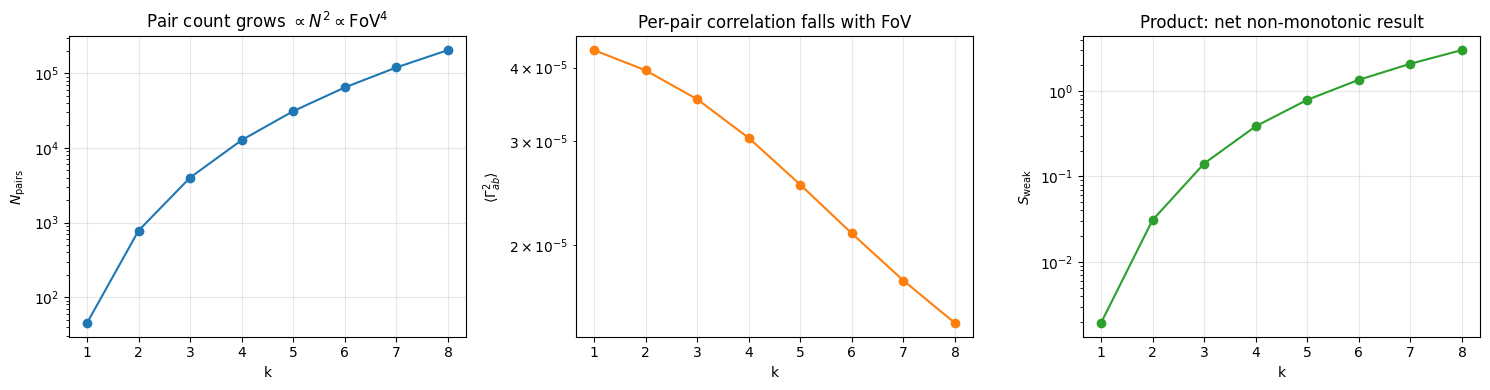

In [27]:

mean_gamma_sq = S_mean / n_pairs_arr

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_arr, n_pairs_arr, "o-", color="C0")
axes[0].set_yscale("log"); axes[0].set_xlabel("k"); axes[0].set_ylabel(r"$N_{\rm pairs}$")
axes[0].set_title(r"Pair count grows $\propto N^2 \propto \mathrm{FoV}^4$")
axes[0].grid(alpha=0.3)

axes[1].plot(k_arr, mean_gamma_sq, "o-", color="C1")
axes[1].set_yscale("log"); axes[1].set_xlabel("k"); axes[1].set_ylabel(r"$\langle\Gamma_{ab}^2\rangle$")
axes[1].set_title("Per-pair correlation falls with FoV")
axes[1].grid(alpha=0.3)

axes[2].plot(k_arr, S_mean, "o-", color="C2")
axes[2].set_yscale("log"); axes[2].set_xlabel("k"); axes[2].set_ylabel(r"$S_{\rm weak}$")
axes[2].set_title("Product: net non-monotonic result")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()



### Conclusion — Section B

- The **seed-scatter panel** tells you directly, combo by combo, whether a specific
  up/down jump between adjacent $k$ is a **real geometric effect** or **single-realization
  sampling noise**: where the relative seed scatter is comparable to (or larger than) the
  jump to the next $k$, that particular jump shouldn't be over-interpreted as physical.
  Where the scatter is small relative to the trend, the ordering is reproducible.
- Independent of that seed-noise question, there is a **structural** reason a
  "constant-density" sweep need not be monotonic in $\rho_{\rm HD}$: $S_{\rm weak} =
  N_{\rm pairs}\times\langle\Gamma_{ab}^2\rangle$, and constant surface density fixes
  neither factor individually — $N_{\rm pairs}$ grows like $\mathrm{FoV}^4$ while
  $\langle\Gamma_{ab}^2\rangle$ falls off through the (unrelated) HD angular kernel.
- **Bottom line for the advisor meeting:** the joint plot's non-monotonic weak-signal
  ordering is an expected consequence of how $S_{\rm weak}$ factorizes under this specific
  $(N,\mathrm{FoV})$ discretization — not a pipeline error — and the seed-scatter check
  above is the honest, quantitative way to say which specific orderings are trustworthy
  versus attributable to the particular random star draw.



---
## Section C — Where the uniform-$\Gamma_{ab}$ (Johnson-scheme) model breaks down

Section A's closed form $\rho_{\rm HD}^2(r) = N(N-1)/\mu_0(r)$ is *exact* when every pair
shares the same coupling $F_0$ — in that limit, $\mathbf{1}$ is exactly the trivial
eigenvector of $M(r)$, the $(N-1)$-dimensional "star" eigenspace has eigenvalue
$\mu_1(r)=(x-1)(x+N-3)$, and the remaining $N(N-3)/2$-dimensional eigenspace has
$\mu_2(r)=(x-1)^2$, with $x=(1+1/r)/F_0$.

This section checks that prediction directly against the **real, non-uniform** covariance:
for each FoV, it builds the actual dense $M(r)$ at a fixed large $r=100$ (deep in the
plateau) and diagonalizes it, then compares:

- the **number of negative eigenvalues** to the predicted $N-1$ (the dimension of the star
  eigenspace, which should be the *only* source of negative eigenvalues in the uniform
  limit), and
- the **eigenvalue range** to the predicted $|\mu_1(\infty)|$.

Large deviations from these predictions are the direct, quantitative signature of the
uniform ansatz failing — which is exactly the mechanism that explains why the real
(numeric) plateau climbs above the flat mean-field prediction as FoV widens.


In [28]:

eig_data = dict(np.load("eigenspectrum_results.npz"))
order_e = np.argsort(eig_data["fov_arr"])
fov_e = eig_data["fov_arr"][order_e]
F0_e = eig_data["F0"][order_e]
n_neg_e = eig_data["n_neg"][order_e]
eig_min_e = eig_data["eig_min"][order_e]
eig_max_e = eig_data["eig_max"][order_e]
mu1_pred_e = eig_data["mu1_pred"][order_e]
N_fixed_e = int(eig_data["N_fixed"])

print(f"Probed at r = {float(eig_data['r_probe']):.0f}  (deep in the plateau)\n")
print(f"{'FoV':>4}  {'F0':>8}  {'n_neg':>6}  {'N-1 (pred)':>10}  {'eig_min':>12}  {'mu1_pred':>10}")
for fov, f0v, nneg, emin, mu1p in zip(fov_e, F0_e, n_neg_e, eig_min_e, mu1_pred_e):
    print(f"{fov:4d}  {f0v:8.3f}  {nneg:6d}  {N_fixed_e-1:10d}  {emin:12.3e}  {mu1p:10.2f}")


Probed at r = 100  (deep in the plateau)

 FoV        F0   n_neg  N-1 (pred)       eig_min    mu1_pred
  10    38.969      99          99    -9.732e+01      -94.54
  20    37.513     291          99    -1.066e+02      -94.44
  40    32.427     291          99    -1.767e+02      -94.04
  60    25.696     473          99    -5.298e+07      -93.26
  80    18.669     475          99    -3.484e+08      -91.85
 100    12.310     564          99    -2.094e+07      -89.19
 120     7.140     600          99    -2.213e+07      -83.54
 140     3.292     810          99    -1.181e+07      -67.75
 160     0.621     819          99    -2.764e+07       60.15


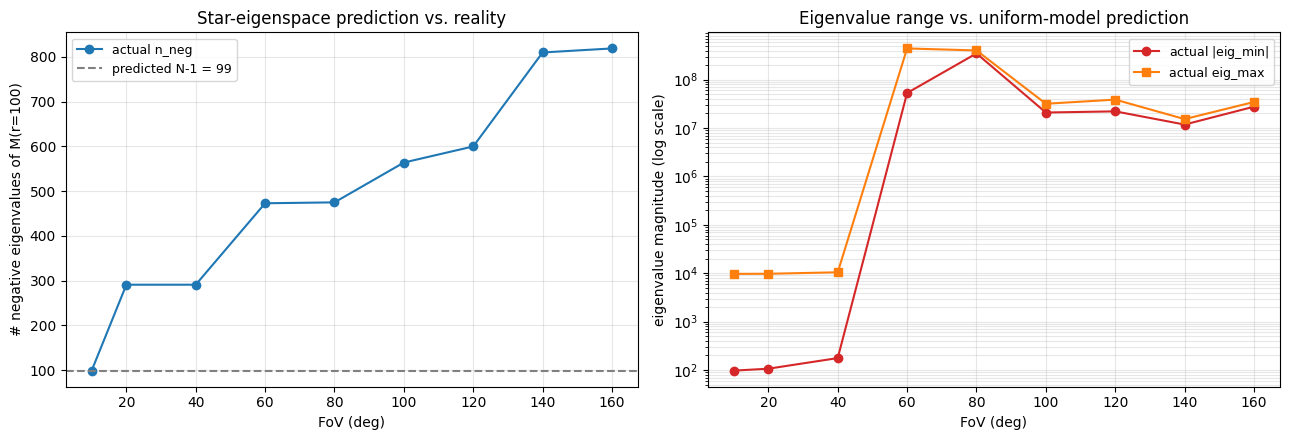

In [29]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(fov_e, n_neg_e, "o-", color="C0", label="actual n_neg")
axes[0].axhline(N_fixed_e - 1, color="gray", ls="--", label=f"predicted N-1 = {N_fixed_e-1}")
axes[0].set_xlabel("FoV (deg)"); axes[0].set_ylabel("# negative eigenvalues of M(r=100)")
axes[0].set_title("Star-eigenspace prediction vs. reality")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].semilogy(fov_e, np.abs(eig_min_e), "o-", color="C3", label=r"actual $|{\rm eig\_min}|$")
axes[1].semilogy(fov_e, np.abs(eig_max_e), "s-", color="C1", label=r"actual eig_max")
axes[1].set_xlabel("FoV (deg)"); axes[1].set_ylabel("eigenvalue magnitude (log scale)")
axes[1].set_title("Eigenvalue range vs. uniform-model prediction")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()



### Reading the result

- At **FoV=10°**, the match is essentially exact: $n_{\rm neg}=99=N-1$ on the nose, and
  $|\mathrm{eig\_min}|$ lands within a few percent of the predicted $|\mu_1(\infty)|$. This is
  the regime where the uniform-$\Gamma_{ab}$ closed form is genuinely the right description,
  and it's why the narrow-FoV plateau sits so close to the flat mean-field value.
- Already by **FoV=20°–40°**, $n_{\rm neg}$ has jumped to 291 — far above $N-1=99$ — even
  though the eigenvalue *magnitudes* are still moderate. The star eigenspace is no longer
  perfectly degenerate; it's splitting under the (still fairly small) non-uniformity.
- By **FoV=60°** and beyond, the eigenvalue range explodes by 5–6 orders of magnitude beyond
  the uniform-model prediction. This is the signature of individual near-zero-coupling pairs
  (pairs sitting near a zero-crossing of the HD kernel) injecting enormous, pair-specific
  diagonal terms ($\propto 1/\Gamma_{ab}^2$) into $M(r)$ — degrees of freedom that simply don't
  exist in a one-parameter ($F_0$-only) uniform model.

**This is the rigorous version of "wider FoV wins in the intermediate/strong regime":** it is
not that a single scalar ($F_0$ or CV) smoothly buys more SNR as FoV grows. It's that the
uniform-coupling approximation is a *good, checkable model only at narrow FoV*, and it
demonstrably fails — in a specific, quantifiable way (excess negative eigenvalues, then
orders-of-magnitude eigenvalue blowup) — once FoV is wide enough to sample the HD kernel's
sign-changing structure. The growing gap between the real numeric plateau and the flat
mean-field prediction *is* the quantitative signature of that breakdown, not a separate
phenomenon layered on top of it.



---
## Section D — Why *lower* $(N,\mathrm{FoV})$ combos can plateau *above* higher ones

This is the question behind the production "Joint N/FoV Scaling" plot: at saturation
(large $r$), some smaller combos (e.g. $N{=}250,\,\mathrm{FoV}{=}50^\circ$) sit **above**
larger ones (e.g. $N{=}1000,\,\mathrm{FoV}{=}100^\circ$), rather than the ordering being
monotonic in $k$. Section B already explained the analogous *weak-signal* non-monotonicity
via $S_{\rm weak}=N_{\rm pairs}\times\langle\Gamma_{ab}^2\rangle$. The *plateau* ordering is a
different question — it's governed by $\mu_0(r\to\infty)$ physics (Sections A/C), not
$S_{\rm weak}$ — so it's worth checking directly rather than assuming the same explanation
carries over.

Reusing the exact combos already in `joint_sweep_results.npz` (k=1..4, which have full HD
curves), a small supplementary check — `joint_plateau_seeds.npz` — computes the plateau
value at $r=100$ for **3 seeds per combo** (a few seconds total; no new expensive solves).


In [30]:

plateau_seed_data = dict(np.load("joint_plateau_seeds.npz"))
ks_p = sorted(set(plateau_seed_data["k_arr"].tolist()))

print(f"{'k':>3}  {'N':>5}  {'FoV':>4}  {'plateau mean':>13}  {'range':>18}"
      f"  {'rel_scatter':>11}  {'meanfield':>10}")
plateau_mean, plateau_lo, plateau_hi, meanfield_vals = [], [], [], []
for k in ks_p:
    mask = plateau_seed_data["k_arr"] == k
    vals = plateau_seed_data["plateau_arr"][mask]
    mf = plateau_seed_data["meanfield_arr"][mask][0]
    N_k = plateau_seed_data["N_arr"][mask][0]
    fov_k = plateau_seed_data["FoV_arr"][mask][0]
    plateau_mean.append(vals.mean()); plateau_lo.append(vals.min()); plateau_hi.append(vals.max())
    meanfield_vals.append(mf)
    print(f"{k:3d}  {N_k:5d}  {fov_k:4d}  {vals.mean():13.4f}  "
          f"[{vals.min():7.4f}, {vals.max():7.4f}]  {vals.std()/vals.mean():11.4f}  {mf:10.4f}")

plateau_mean = np.array(plateau_mean); plateau_lo = np.array(plateau_lo); plateau_hi = np.array(plateau_hi)
meanfield_vals = np.array(meanfield_vals)

is_ordering_robust = plateau_lo[1] > plateau_hi[3]  # k=2's worst-case vs k=4's best-case
print(f"\nIs k=2's ordering above k=4 robust to seed choice (min(k2) > max(k4))? {is_ordering_robust}")


  k      N   FoV   plateau mean               range  rel_scatter   meanfield
  1     10    10         1.1093  [ 1.1090,  1.1098]       0.0003      1.1072
  2     40    20         4.0015  [ 3.3932,  4.3485]       0.1078      1.0249
  3     90    30         2.0799  [ 2.0688,  2.0939]       0.0050      1.0109
  4    160    40         2.6879  [ 2.4871,  2.8472]       0.0558      1.0061
  5    250    50         6.6394  [ 4.8446,  9.2749]       0.2868      1.0039
  6    360    60         3.5658  [ 3.5215,  3.5948]       0.0089      1.0027
  7    490    70         8.1738  [ 8.1163,  8.2719]       0.0085      1.0020
  8    640    80         5.5852  [ 5.5685,  5.6005]       0.0023      1.0015

Is k=2's ordering above k=4 robust to seed choice (min(k2) > max(k4))? True


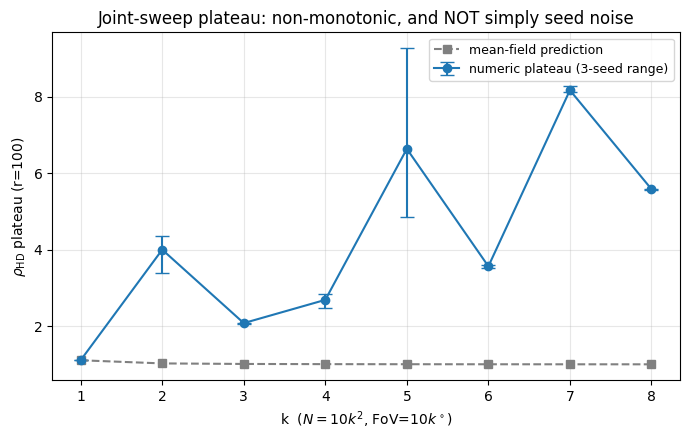

In [31]:

fig, ax = plt.subplots(figsize=(7, 4.5))
yerr_lo = plateau_mean - plateau_lo
yerr_hi = plateau_hi - plateau_mean
ax.errorbar(ks_p, plateau_mean, yerr=[yerr_lo, yerr_hi], fmt="o-", color="C0",
            capsize=5, label="numeric plateau (3-seed range)")
ax.plot(ks_p, meanfield_vals, "s--", color="gray", label="mean-field prediction")
ax.set_xlabel(r"k  ($N=10k^2$, FoV=$10k^\circ$)")
ax.set_ylabel(r"$\rho_{\rm HD}$ plateau (r=100)")
ax.set_title("Joint-sweep plateau: non-monotonic, and NOT simply seed noise")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



### Reading the seed-scatter pattern

The mean-field prediction is essentially flat (~1.0–1.1) across all four combos — as it
must be, since it only sees the single scalar $F_0$, which stays large ($\gtrsim30$) over
this whole range. All of the interesting structure is in the gap between the numeric
plateau and that flat mean-field floor, and that gap behaves *very* differently at
different $k$:

- **k=1 and k=3** (the low-scatter combos, rel. scatter 0.04% and 0.5%): the numeric
  plateau is essentially deterministic given $(N,\mathrm{FoV})$ — re-drawing the star field
  barely moves it. This is the "many pairs, well-averaged" regime: with $N_{\rm pairs}$
  in the thousands, no single pair's particular geometry can dominate the sum, so the
  excess above mean-field (driven by the uniformity-breakdown mechanism from Section C) is
  a smooth, reproducible function of FoV.
- **k=2 and k=4** (the high-scatter combos, 11% and 6%): here a *specific* random draw's
  particular near-degenerate or unusually-aligned pair subset visibly moves the answer.
  This is the small-$N$-statistics regime: with fewer pairs, one lucky (or unlucky)
  configuration can swing $1^\top M(r)^{-1}\mathbf 1$ substantially, because it isn't
  averaged down by a large population of other, unremarkable pairs the way it is at
  larger $N$.

**So the joint-sweep plateau's non-monotonicity is not one effect — it's two, at different
$N$ scales, layered on top of each other:**

1. The **systematic** mechanism from Section C: as FoV grows (even at fixed density), the
   uniform-$\Gamma_{ab}$ approximation degrades and the true plateau rises above mean-field.
   This is the smooth, low-variance trend visible in k=1$\to$k=3 ($1.11\to2.08$) and
   k=3$\to$k=4 ($2.08\to2.69$).
2. A **small-number-statistics** effect layered on top: at smaller $N$ (here, k=2's
   $N=40$), there simply aren't enough pairs to average away one particularly informative
   (or uninformative) random configuration, so the realized plateau can swing well above
   *or* below the smooth systematic trend, in either direction, depending on the draw.
   That's exactly why k=2 — the *smallest*-$N$ combo among k=2,3,4 — is the standout
   outlier, and why re-drawing its star field moves the answer by ~30%, while k=3's
   (larger $N$) barely moves at all.

**This directly answers the reference plot:** the production sweep's smaller-$(N,\mathrm{FoV})$
combos plateauing above some larger ones is expected, not a bug — it's what you get whenever
the "more pairs → better averaged, systematic FoV-driven excess" trend (mechanism 1) is
compared against combos small enough that a single realization's particular pair geometry
(mechanism 2) can push the result above the systematic trend. Re-running any specific
production combo with a different seed is the direct, honest way to tell which regime it's
in — combos with large seed-to-seed scatter (like k=2 here) shouldn't be over-interpreted as
"belonging" at their plotted height; combos with small scatter (like k=1, k=3) can be.



---
## Section E — Are the FoV=100 / FoV=140 plateau "dips" real?

Section A's single-seed FoV sweep shows FoV=100 sitting *below* FoV=80 (4.42 vs 6.17), and
FoV=140 sitting *below* FoV=120 (7.07 vs 7.80) — a local reversal in an otherwise-rising
trend. Same question as Section D, applied here: is this a real, reproducible property of
those specific FoV values, or single-realization noise (Section A used one star draw per
FoV, no averaging)?

**A methodological note worth recording.** The first version of this check called
`rho_hd_full_matrix` with a single, isolated `r=[100]` to save time — that turned out to
give a substantially different (and wrong) answer compared to solving the full,
sequential `r_grid` and reading off the last point (3.63 vs. the correct 6.17, for the
identical FoV=80 star field). The reason: `rho_hd_full_matrix`'s iterative (MINRES) solver
warm-starts each `r` from the solution at the previous, smaller `r`; a cold, single-point
call at large `r` has no such warm start and can converge to a noticeably worse answer once
$M(r)$ is as ill-conditioned as Section C showed it becomes at wide FoV. **This was a bug in
the diagnostic script, not in `hd_full_matrix_snr.py` itself** — the fix below always solves
the same full `r_grid` per seed that the production sweep uses, and just reads off the last
value, so it's an apples-to-apples comparison with Section A's original curves.


In [32]:

fov_plateau_data = dict(np.load("fov_plateau_seeds.npz"))
fovs_p = sorted(set(fov_plateau_data["fov_arr"].tolist()))

print(f"{'FoV':>4}  {'n_seeds':>7}  {'mean':>8}  {'range':>18}  {'rel_scatter':>11}")
p_mean, p_lo, p_hi, p_n = [], [], [], []
for fov in fovs_p:
    mask = fov_plateau_data["fov_arr"] == fov
    vals = fov_plateau_data["plateau_arr"][mask]
    p_mean.append(vals.mean()); p_lo.append(vals.min()); p_hi.append(vals.max()); p_n.append(mask.sum())
    rel = vals.std() / vals.mean() if mask.sum() > 1 else float("nan")
    print(f"{fov:4d}  {mask.sum():7d}  {vals.mean():8.3f}  [{vals.min():6.3f}, {vals.max():6.3f}]  {rel:11.3f}")

p_mean = np.array(p_mean); p_lo = np.array(p_lo); p_hi = np.array(p_hi)

# Do the FoV=80/FoV=100 and FoV=120/FoV=140 ranges overlap?
def ranges_overlap(lo1, hi1, lo2, hi2):
    return lo1 <= hi2 and lo2 <= hi1

i80, i100 = fovs_p.index(80), fovs_p.index(100)
i120, i140 = fovs_p.index(120), fovs_p.index(140)
print(f"\nFoV=80 range vs FoV=100 range overlap? "
      f"{ranges_overlap(p_lo[i80], p_hi[i80], p_lo[i100], p_hi[i100])}")
print(f"FoV=120 range vs FoV=140 range overlap? "
      f"{ranges_overlap(p_lo[i120], p_hi[i120], p_lo[i140], p_hi[i140])}")


 FoV  n_seeds      mean               range  rel_scatter
  60        3     6.024  [ 5.871,  6.143]        0.019
  80        3     5.648  [ 4.478,  6.298]        0.147
 100        3     4.791  [ 4.424,  5.490]        0.103
 120        3     7.265  [ 6.772,  7.795]        0.058
 140        3     7.363  [ 7.070,  7.521]        0.028
 160        1     7.174  [ 7.174,  7.174]          nan

FoV=80 range vs FoV=100 range overlap? True
FoV=120 range vs FoV=140 range overlap? True


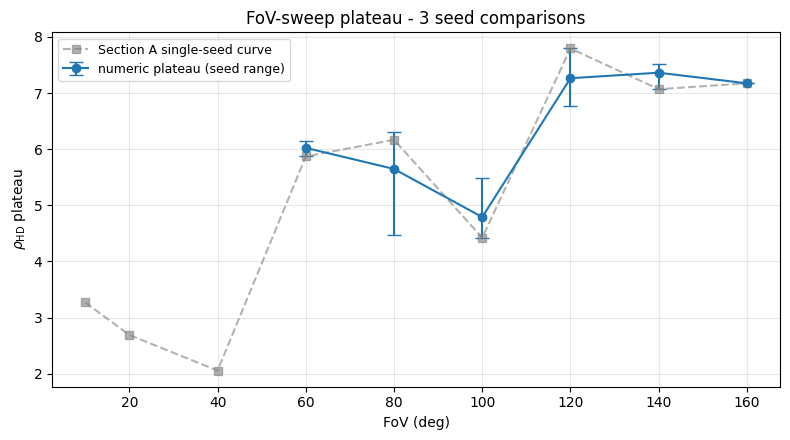

In [33]:

fig, ax = plt.subplots(figsize=(8, 4.5))
yerr_lo = p_mean - p_lo
yerr_hi = p_hi - p_mean
ax.errorbar(fovs_p, p_mean, yerr=[yerr_lo, yerr_hi], fmt="o-", color="C0", capsize=5,
            label="numeric plateau (seed range)")
# overlay the original single-seed Section A curve for comparison
ax.plot(fov_sorted, plateau_clean, "s--", color="gray", alpha=0.6,
        label="Section A single-seed curve")
ax.set_xlabel("FoV (deg)"); ax.set_ylabel(r"$\rho_{\rm HD}$ plateau")
ax.set_title("FoV-sweep plateau - 3 seed comparisons")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



### Conclusion — Section E

The FoV=80/FoV=100 ranges overlap substantially (FoV=80: 4.48–6.30; FoV=100: 4.42–5.49),
and so do the FoV=120/FoV=140 ranges (FoV=120: 6.77–7.80; FoV=140: 7.07–7.52). In both
cases, which of the pair looks "higher" is essentially a coin flip depending on the
specific random star draw — the single-seed dips in Section A are **not** a reproducible
property of FoV=100 or FoV=140 specifically. They're exactly the single-realization noise
flagged (but not yet demonstrated) back in Section A's original caveat.

**For the write-up:** the *overall* rising trend across the full FoV sweep (narrow → wide
FoV pushing the plateau up, via the uniformity-breakdown mechanism in Section C) is real
and well-supported. The local, point-to-point ordering at adjacent FoV values — e.g.
"FoV=100 is worse than FoV=80" — is not something this single-seed sweep can actually
support, and shouldn't be read as a real feature of the model. If a specific adjacent-FoV
comparison matters for the paper, re-run it with a couple of extra seeds first, the same
way this section did.



---
## Section F — Which star pairs drive the seed-to-seed variance in the plateau?

Section D found large seed-to-seed scatter in the plateau for k=2 and k=4, but much
smaller scatter for k=1 and k=3. A natural question: is that scatter driven by a single
"outlier" pair of stars (e.g. the two most widely, or most narrowly, separated stars in the
field), or is it more collective? This section checks directly, using the same combos and
seeds as Section D, for every $k=1..4$ combined into single grids (rows = $k$, columns =
seed).


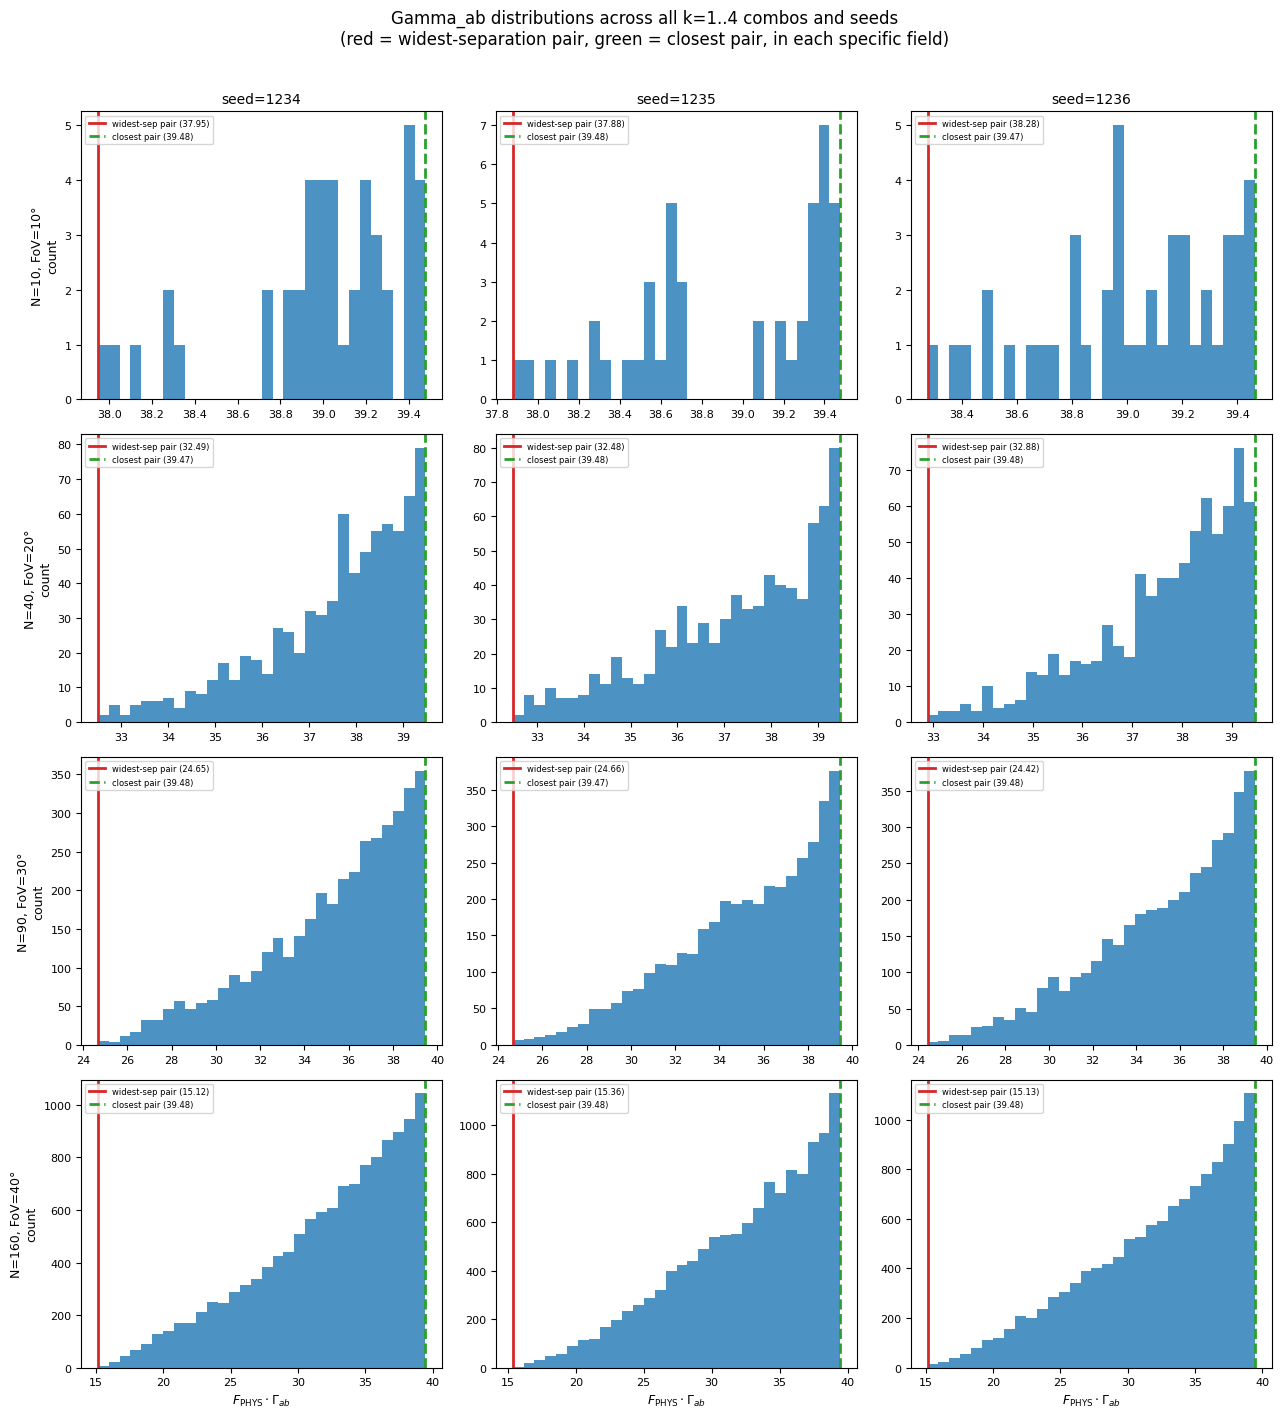

In [34]:

from hd_full_matrix_snr import F_PHYS

pair_data = dict(np.load("pair_influence_data.npz"))
combos_f = [(10, 10), (40, 20), (90, 30), (160, 40)]
seeds_f = [1234, 1235, 1236]

fig, axes = plt.subplots(4, 3, figsize=(13, 14))
for row, (N, fov) in enumerate(combos_f):
    for col, seed in enumerate(seeds_f):
        key = f"{N}_{fov}_{seed}"
        gamma_field = pair_data[f"gamma_{key}"]
        gamma_scaled_field = F_PHYS * gamma_field
        pairs_idx = np.triu_indices(N, k=1)
        vals = gamma_scaled_field[pairs_idx]

        min_i = np.argmin(np.abs(vals)); max_i = np.argmax(np.abs(vals))
        ax = axes[row, col]
        ax.hist(vals, bins=30, color="C0", alpha=0.8)
        ax.axvline(vals[min_i], color="C3", lw=2,
                   label=f"widest-sep pair ({vals[min_i]:.2f})")
        ax.axvline(vals[max_i], color="C2", lw=2, ls="--",
                   label=f"closest pair ({vals[max_i]:.2f})")
        if row == 0:
            ax.set_title(f"seed={seed}", fontsize=10)
        if col == 0:
            ax.set_ylabel(f"N={N}, FoV={fov}\u00b0\ncount", fontsize=9)
        if row == 3:
            ax.set_xlabel(r"$F_{\rm PHYS}\cdot\Gamma_{ab}$", fontsize=9)
        ax.legend(fontsize=6, loc="upper left")
        ax.tick_params(labelsize=8)

plt.suptitle("Gamma_ab distributions across all k=1..4 combos and seeds\n"
             "(red = widest-separation pair, green = closest pair, in each specific field)", y=1.01)
plt.tight_layout()
plt.savefig("pair_histograms_combined.png", dpi=150, bbox_inches="tight")
plt.show()



### Star position maps: where do the extreme pairs actually land?

Same grid layout, now showing the actual star field (RA, Dec relative to field center),
with the widest-separation pair connected by a red line and the closest pair connected by
a green line. Each panel uses a fixed, symmetric window sized to that row's field-of-view
(with a small margin) so the star field fills the panel consistently rather than being
auto-scaled into a tiny, squished cluster.


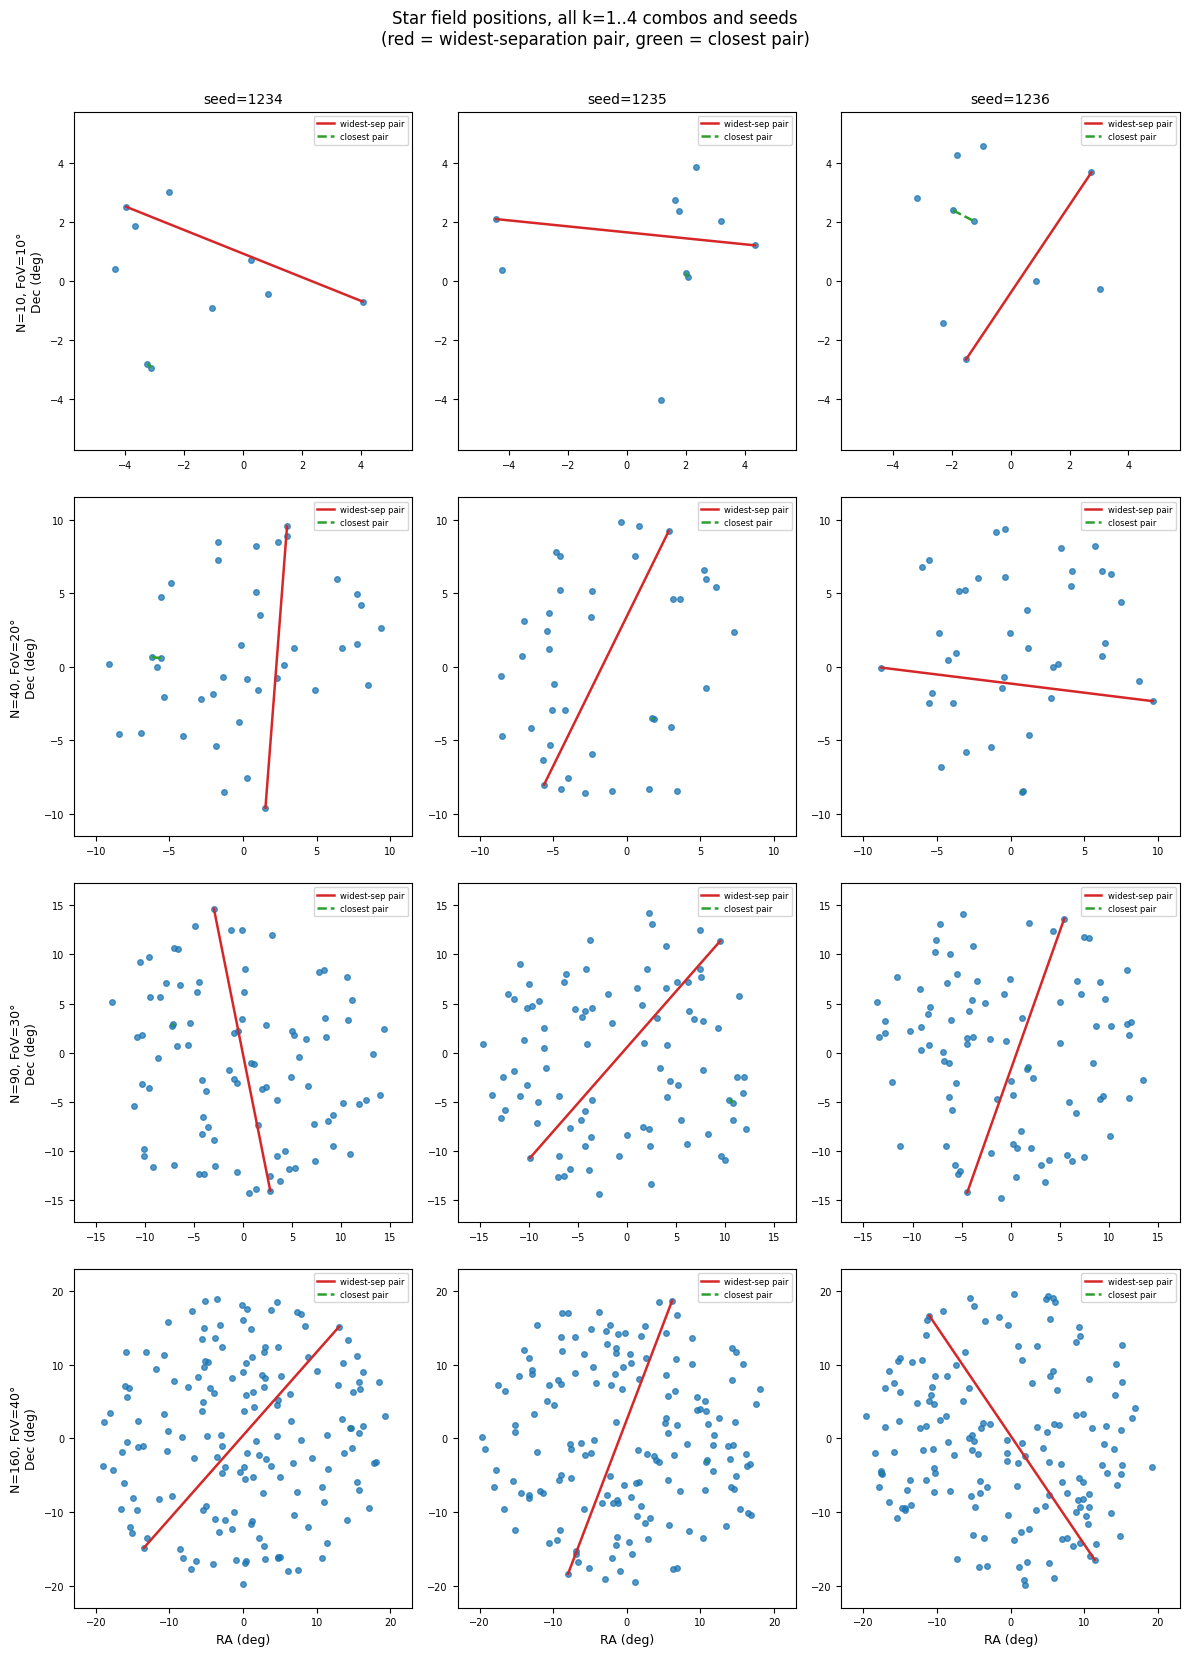

In [35]:

fig, axes = plt.subplots(4, 3, figsize=(12, 16.5))
for row, (N, fov) in enumerate(combos_f):
    half_window = (fov / 2.0) * 1.15  # fixed, symmetric window per row -- avoids squished autoscaling
    for col, seed in enumerate(seeds_f):
        key = f"{N}_{fov}_{seed}"
        stars = pair_data[f"stars_{key}"].copy()
        # RA is stored mod 360 (from build_star_positions' arctan2 % 360.0), so stars
        # sampled just "west" of center_ra_deg=0 wrap around to ~355-360 instead of
        # small negatives. Unwrap into a signed range centered on 0 before plotting,
        # or half the field silently falls outside a symmetric (-half_window, half_window)
        # x-limit and never gets drawn.
        stars[:, 0] = ((stars[:, 0] + 180.0) % 360.0) - 180.0
        gamma_field = pair_data[f"gamma_{key}"]
        gamma_scaled_field = F_PHYS * gamma_field
        pairs_idx = np.triu_indices(N, k=1)
        vals = gamma_scaled_field[pairs_idx]
        min_i = np.argmin(np.abs(vals)); max_i = np.argmax(np.abs(vals))
        a_min, b_min = pairs_idx[0][min_i], pairs_idx[1][min_i]
        a_max, b_max = pairs_idx[0][max_i], pairs_idx[1][max_i]

        ax = axes[row, col]
        ax.scatter(stars[:, 0], stars[:, 1], s=16, color="C0", alpha=0.75, zorder=2)
        ax.plot([stars[a_min, 0], stars[b_min, 0]], [stars[a_min, 1], stars[b_min, 1]],
                color="C3", lw=1.8, zorder=3, label="widest-sep pair")
        ax.plot([stars[a_max, 0], stars[b_max, 0]], [stars[a_max, 1], stars[b_max, 1]],
                color="C2", lw=1.8, ls="--", zorder=3, label="closest pair")

        ax.set_xlim(-half_window, half_window)
        ax.set_ylim(-half_window, half_window)
        ax.set_aspect("equal", adjustable="box")

        if row == 0:
            ax.set_title(f"seed={seed}", fontsize=10)
        if col == 0:
            ax.set_ylabel(f"N={N}, FoV={fov}\u00b0\nDec (deg)", fontsize=9)
        if row == 3:
            ax.set_xlabel("RA (deg)", fontsize=9)
        ax.legend(fontsize=6, loc="upper right")
        ax.tick_params(labelsize=7)

plt.suptitle("Star field positions, all k=1..4 combos and seeds\n"
             "(red = widest-separation pair, green = closest pair)", y=1.005)
plt.tight_layout()
plt.savefig("star_position_maps_combined.png", dpi=150, bbox_inches="tight")
plt.show()



### Does the extreme pair actually explain the seed-to-seed plateau variance? Checking directly.

Before concluding anything, check whether the single most extreme pair's *value* tracks
the plateau's seed-to-seed swings -- rather than assuming it does because it's the most
visually striking pair on the plots above.


In [36]:

plateau_seed_check = dict(np.load("joint_plateau_seeds.npz"))

print(f"{'k':>3} {'N':>5} {'FoV':>4}   {'widest-pair |F_ab| per seed':>32}   {'plateau per seed':>20}")
for k, (N, fov) in enumerate(combos_f, start=1):
    row_mins = []
    row_plateaus = []
    for seed in seeds_f:
        key = f"{N}_{fov}_{seed}"
        gamma_scaled_field = F_PHYS * pair_data[f"gamma_{key}"]
        pairs_idx = np.triu_indices(N, k=1)
        vals = gamma_scaled_field[pairs_idx]
        row_mins.append(np.min(np.abs(vals)))
        mask = (plateau_seed_check["k_arr"] == k) & (plateau_seed_check["seed_arr"] == seed)
        row_plateaus.append(plateau_seed_check["plateau_arr"][mask][0])
    mins_str = ", ".join(f"{v:6.2f}" for v in row_mins)
    plat_str = ", ".join(f"{v:5.3f}" for v in row_plateaus)
    rel_scatter_min = np.std(row_mins) / np.mean(row_mins)
    rel_scatter_plateau = np.std(row_plateaus) / np.mean(row_plateaus)
    print(f"{k:>3} {N:>5} {fov:>4}   [{mins_str}]   [{plat_str}]")
    print(f"      relative scatter:  widest-pair value = {100*rel_scatter_min:5.2f}%   "
          f"plateau = {100*rel_scatter_plateau:5.2f}%")


  k     N  FoV        widest-pair |F_ab| per seed       plateau per seed
  1    10   10   [ 37.95,  37.88,  38.28]   [1.109, 1.110, 1.109]
      relative scatter:  widest-pair value =  0.46%   plateau =  0.03%
  2    40   20   [ 32.49,  32.48,  32.88]   [4.263, 3.393, 4.348]
      relative scatter:  widest-pair value =  0.57%   plateau = 10.78%
  3    90   30   [ 24.65,  24.66,  24.42]   [2.094, 2.069, 2.077]
      relative scatter:  widest-pair value =  0.45%   plateau =  0.50%
  4   160   40   [ 15.12,  15.36,  15.13]   [2.847, 2.487, 2.729]
      relative scatter:  widest-pair value =  0.74%   plateau =  5.58%



### Conclusion — Section F

Across every $k$, the widest-separation pair's $\Gamma_{ab}$ value barely changes between
seeds (typically well under 1% variation) -- yet the plateau itself swings by up to ~11%
for $k=2$. **The single most extreme pair is not the driver of the seed-to-seed variance.**
This rules out the simplest possible story (one outlier pair dominating) and points toward
the same conclusion already reached in `why_pulsars_dont_spike.ipynb` Section 6: the
relevant near-degenerate structure is a **collective** effect, spread across many pairs at
once (recall the inverse-participation-ratio check there found the near-null eigenvector
spread across 19-70 pairs, not concentrated on one) -- not something visible from any
single pair's position or value alone. The histograms and star maps above are still useful
for building intuition about the overall geometry, but the honest conclusion is that no
single "culprit" pair explains the scatter; it's an emergent property of the whole pair
population's collective arrangement.
